# 7. Modelowanie predykcyjne

W tej części pracy przeprowadzono budowę oraz porównanie modeli predykcyjnych służących do estymacji ceny ofertowej nieruchomości. Analizie poddano zarówno klasyczne modele regresyjne, jak i modele typu ensemble. Dodatkowo oceniono wpływ danych tekstowych na jakość predykcji.

## 7.1. Regresja liniowa

W pierwszym etapie modelowania zastosowano regresję liniową jako model bazowy służący do oceny wpływu cech numerycznych oraz danych tekstowych na jakość predykcji ceny nieruchomości.

In [24]:
# ============================================================
# Import bibliotek
# ============================================================

import pandas as pd
import numpy as np

from scipy.sparse import load_npz, hstack

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

import joblib

In [25]:
# ============================================================
# Wczytanie zapisanych obiektów
# ============================================================


tfidf_vectorizer = joblib.load(
    "tfidf_vectorizer.pkl"
)

In [26]:
# ============================================================
# Wczytanie przygotowanych danych
# ============================================================

df_model = pd.read_csv("df_model.csv")

train_df = pd.read_csv("train_df.csv")
test_df = pd.read_csv("test_df.csv")

X_full_train = load_npz("X_train_full.npz")
X_full_test = load_npz("X_test_full.npz")

y_train = pd.read_csv("y_train.csv").squeeze("columns")
y_test = pd.read_csv("y_test.csv").squeeze("columns")

print("df_model:", df_model.shape)

print("train_df:", train_df.shape)
print("test_df:", test_df.shape)

print("X_full_train:", X_full_train.shape)
print("X_full_test:", X_full_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

df_model: (7934, 14)
train_df: (6347, 14)
test_df: (1587, 14)
X_full_train: (6347, 1003)
X_full_test: (1587, 1003)
y_train: (6347,)
y_test: (1587,)


In [27]:
# ============================================================
# Przygotowanie zbiorów cech
# ============================================================

numeric_features = [
    "log_sqft",
    "beds",
    "baths"
]

numeric_imputer = joblib.load(
    "numeric_imputer.pkl"
)

X_num_train = numeric_imputer.transform(
    train_df[numeric_features]
)

X_num_test = numeric_imputer.transform(
    test_df[numeric_features]
)

print("X_num_train:", X_num_train.shape)
print("X_num_test:", X_num_test.shape)

X_num_train: (6347, 3)
X_num_test: (1587, 3)


In [28]:
# ============================================================
# Funkcja oceny modelu
# ============================================================

def evaluate_model(model_name, y_true_log, y_pred_log):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)

    return {
        "model": model_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2_log": r2_score(y_true_log, y_pred_log)
    }

In [29]:
# ============================================================
# Model 1: Regresja liniowa na cechach numerycznych
# ============================================================

linear_numeric = LinearRegression()

linear_numeric.fit(
    X_num_train,
    y_train
)

y_pred_numeric = linear_numeric.predict(
    X_num_test
)

results = []

results.append(
    evaluate_model(
        "Linear Regression - cechy numeryczne",
        y_test,
        y_pred_numeric
    )
)

In [30]:
# ============================================================
# Model 2: Regresja liniowa na cechach numerycznych i tekstowych
# ============================================================

linear_full = LinearRegression()

linear_full.fit(
    X_full_train,
    y_train
)

y_pred_full = linear_full.predict(
    X_full_test
)

results.append(
    evaluate_model(
        "Linear Regression - cechy numeryczne + TF-IDF",
        y_test,
        y_pred_full
    )
)

In [31]:
# ============================================================
# Porównanie wyników regresji liniowej
# ============================================================

linear_results = pd.DataFrame(results)

linear_results[["MAE", "RMSE"]] = linear_results[["MAE", "RMSE"]].round(2)
linear_results["R2_log"] = linear_results["R2_log"].round(4)

linear_results

,model,MAE,RMSE,R2_log
0,Linear Regression - cechy numeryczne,925424.88,9484516.20,0.2971
1,Linear Regression - cechy numeryczne + TF-IDF,500761.75,1578008.22,0.6092


## 7.2. Random Forest Regressor

W kolejnym etapie zastosowano model Random Forest Regressor, należący do metod ensemble. Model porównano w dwóch wariantach: z wykorzystaniem wyłącznie cech numerycznych oraz z rozszerzeniem o cechy tekstowe TF-IDF.

In [32]:
# ============================================================
# Model 1: Random Forest na cechach numerycznych
# ============================================================

rf_numeric = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_numeric.fit(
    X_num_train,
    y_train
)

y_pred_rf_numeric = rf_numeric.predict(
    X_num_test
)

results.append(
    evaluate_model(
        "Random Forest - cechy numeryczne",
        y_test,
        y_pred_rf_numeric
    )
)

In [33]:
# ============================================================
# Model 2: Random Forest na cechach numerycznych i tekstowych
# ============================================================

rf_full = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_full.fit(
    X_full_train,
    y_train
)

y_pred_rf_full = rf_full.predict(
    X_full_test
)

results.append(
    evaluate_model(
        "Random Forest - cechy numeryczne + TF-IDF",
        y_test,
        y_pred_rf_full
    )
)

In [34]:
# ============================================================
# Aktualne porównanie wyników modeli
# ============================================================

model_results = pd.DataFrame(results)

model_results[["MAE", "RMSE"]] = model_results[["MAE", "RMSE"]].round(2)
model_results["R2_log"] = model_results["R2_log"].round(4)

model_results

,model,MAE,RMSE,R2_log
0,Linear Regression - cechy numeryczne,925424.88,9484516.20,0.2971
1,Linear Regression - cechy numeryczne + TF-IDF,500761.75,1578008.22,0.6092
2,Random Forest - cechy numeryczne,707362.74,1806783.14,0.2278
3,Random Forest - cechy numeryczne + TF-IDF,478151.12,1505214.63,0.5956


## 7.3. XGBoost Regressor

W kolejnym etapie analizy zastosowano model XGBoost Regressor, należący do grupy metod boostingowych. Model został przeanalizowany zarówno w wariancie wykorzystującym wyłącznie cechy numeryczne, jak i w wersji rozszerzonej o dane tekstowe TF-IDF.

In [35]:
# ============================================================
# Model 1: XGBoost na cechach numerycznych
# ============================================================

xgb_numeric = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_numeric.fit(
    X_num_train,
    y_train
)

y_pred_xgb_numeric = xgb_numeric.predict(
    X_num_test
)

results.append(
    evaluate_model(
        "XGBoost - cechy numeryczne",
        y_test,
        y_pred_xgb_numeric
    )
)

In [36]:
# ============================================================
# Model 2: XGBoost na cechach numerycznych i tekstowych
# ============================================================

xgb_full = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_full.fit(
    X_full_train,
    y_train
)

y_pred_xgb_full = xgb_full.predict(
    X_full_test
)

results.append(
    evaluate_model(
        "XGBoost - cechy numeryczne + TF-IDF",
        y_test,
        y_pred_xgb_full
    )
)

In [37]:
# ============================================================
# Aktualne porównanie wyników modeli
# ============================================================

model_results = pd.DataFrame(results)

model_results[["MAE", "RMSE"]] = model_results[["MAE", "RMSE"]].round(2)
model_results["R2_log"] = model_results["R2_log"].round(4)

model_results

,model,MAE,RMSE,R2_log
0,Linear Regression - cechy numeryczne,925424.88,9484516.20,0.2971
1,Linear Regression - cechy numeryczne + TF-IDF,500761.75,1578008.22,0.6092
2,Random Forest - cechy numeryczne,707362.74,1806783.14,0.2278
3,Random Forest - cechy numeryczne + TF-IDF,478151.12,1505214.63,0.5956
4,XGBoost - cechy numeryczne,652770.48,1760521.92,0.3750
5,XGBoost - cechy numeryczne + TF-IDF,459757.71,1496307.35,0.6425


## 7.4. Porównanie modeli predykcyjnych

W ostatnim etapie analizy porównano skuteczność wszystkich przygotowanych modeli predykcyjnych. Szczególną uwagę poświęcono ocenie wpływu danych tekstowych TF-IDF na jakość predykcji oraz porównaniu skuteczności klasycznych modeli regresyjnych i modeli typu ensemble.

In [38]:
# ============================================================
# Końcowe porównanie modeli
# ============================================================

final_results = model_results.copy()

final_results = final_results.sort_values(
    by="R2_log",
    ascending=False
).reset_index(drop=True)

final_results.index = final_results.index + 1

final_results

,model,MAE,RMSE,R2_log
1,XGBoost - cechy numeryczne + TF-IDF,459757.71,1496307.35,0.6425
2,Linear Regression - cechy numeryczne + TF-IDF,500761.75,1578008.22,0.6092
3,Random Forest - cechy numeryczne + TF-IDF,478151.12,1505214.63,0.5956
4,XGBoost - cechy numeryczne,652770.48,1760521.92,0.3750
5,Linear Regression - cechy numeryczne,925424.88,9484516.20,0.2971
6,Random Forest - cechy numeryczne,707362.74,1806783.14,0.2278


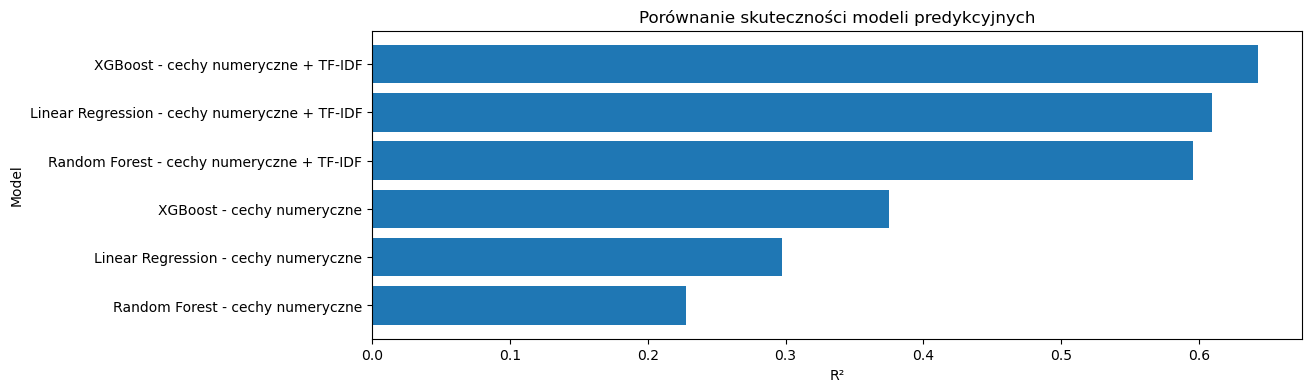

In [39]:
# ============================================================
# Porównanie współczynników R² modeli
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.barh(
    final_results["model"],
    final_results["R2_log"]
)

plt.xlabel("R²")
plt.ylabel("Model")
plt.title("Porównanie skuteczności modeli predykcyjnych")

plt.gca().invert_yaxis()

plt.show()

## 7.5. Analiza wpływu danych tekstowych na predykcję cen nieruchomości

W ostatnim etapie analizy przeprowadzono dodatkową interpretację cech tekstowych wykorzystywanych przez modele predykcyjne. Celem tej części było zidentyfikowanie słów oraz fraz występujących w opisach nieruchomości, które mogły wpływać na przewidywaną cenę ofertową.

In [40]:
# ============================================================
# Analiza wpływu cech tekstowych
# ============================================================

feature_names = (
    numeric_features +
    list(tfidf_vectorizer.get_feature_names_out())
)

coefficients = linear_full.coef_

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

coef_df = coef_df.sort_values(
    by="coefficient",
    ascending=False
)

In [41]:
# ============================================================
# Usunięcie artefaktów NLP z analizy fraz
# ============================================================

bad_tokens = [
    "sac",
    "cul",
    "cul sac",
    "don",
    "en",
    "entity",
    "redacted",
    "redacted entity",
    "conditioning"
]

# ============================================================
# Filtrowanie cech tekstowych
# ============================================================

filtered_coef_df = coef_df[
    ~coef_df["feature"].isin(bad_tokens)
].copy()

In [42]:
# ============================================================
# Najsilniej pozytywne frazy po filtrowaniu
# ============================================================

positive_phrases = filtered_coef_df[
    ~filtered_coef_df["feature"].isin(numeric_features)
].head(20)

positive_phrases

,feature,coefficient
57,attached car,3.492665
989,wood burning fireplace,3.036967
273,en suite,2.794661
548,miele,2.689176
324,feet,2.555751
167,concept,2.553335
671,pre war,2.332910
135,central park,2.238065
553,miss chance,2.147289
908,transportation,1.792310


In [43]:
# ============================================================
# Najsilniej negatywne frazy po filtrowaniu
# ============================================================

negative_phrases = filtered_coef_df[
    ~filtered_coef_df["feature"].isin(numeric_features)
].tail(20)

negative_phrases

,feature,coefficient
545,metro,-1.184016
839,stainless steel,-1.184156
569,natural,-1.218977
59,attached garage,-1.245388
503,little,-1.254965
11,acre lot,-1.262025
963,war,-1.334334
5,abundant natural,-1.345265
421,highlights include,-1.383214
512,long term,-1.537798


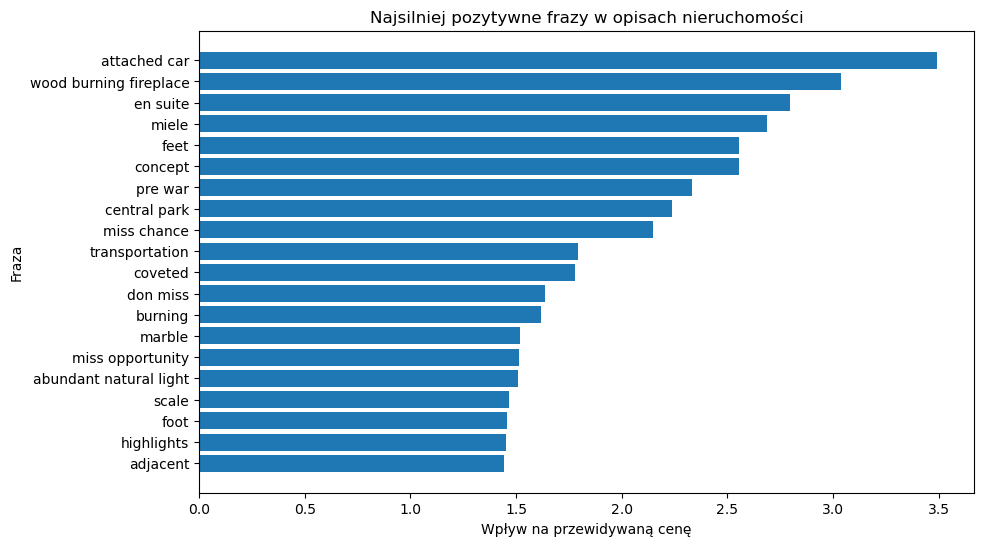

In [44]:
# ============================================================
# Wykres najważniejszych pozytywnych fraz
# ============================================================

import matplotlib.pyplot as plt

top_positive = positive_phrases.sort_values(
    by="coefficient"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_positive["feature"],
    top_positive["coefficient"]
)

plt.xlabel("Wpływ na przewidywaną cenę")
plt.ylabel("Fraza")

plt.title(
    "Najsilniej pozytywne frazy w opisach nieruchomości"
)

plt.show()

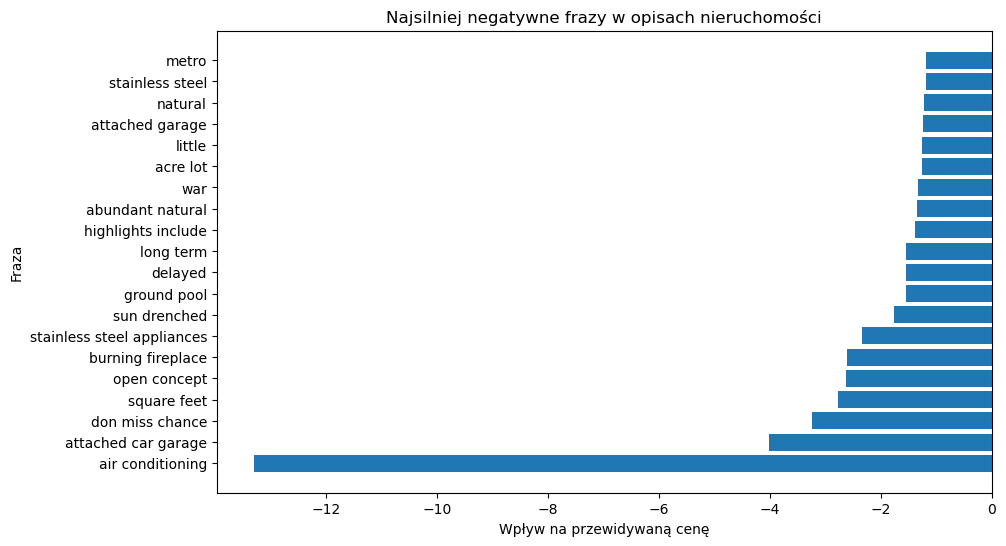

In [45]:
# ============================================================
# Wykres najważniejszych negatywnych fraz
# ============================================================

top_negative = negative_phrases.sort_values(
    by="coefficient"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_negative["feature"],
    top_negative["coefficient"]
)

plt.xlabel("Wpływ na przewidywaną cenę")
plt.ylabel("Fraza")

plt.title(
    "Najsilniej negatywne frazy w opisach nieruchomości"
)

plt.show()